In [1]:
# ============================================================================
# CREDIT CARD FRAUD DETECTION USING SUPPORT VECTOR MACHINE
# ============================================================================
# Replikasi Jurnal: Xia, J. (2022) 
# "Credit Card Fraud Detection Based on Support Vector Machine"
# HSET Vol.23, hal.93-97 | DOI: 10.54097/hset.v23i.3202
# ============================================================================

import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, roc_curve
)

# ============================================================================
# CONFIGURATION
# ============================================================================

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
RANDOM_STATE = 42
DATA_DIR = os.path.join(os.getcwd(), 'data')
MODEL_DIR = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_DIR, exist_ok=True)


In [2]:
# ============================================================================
# STEP 1: LOAD DATASET
# Jurnal hal. 94: gabungkan fraudTrain.csv + fraudTest.csv, ambil 100.000 baris pertama
# ============================================================================

print("=" * 70)
print("STEP 1: LOAD DATASET")
print("=" * 70)

# Load datasets from local folder
df_train = pd.read_csv(os.path.join(DATA_DIR, 'fraudTrain.csv'))
df_test = pd.read_csv(os.path.join(DATA_DIR, 'fraudTest.csv'))

# Combine datasets
df = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total rows combined  : {len(df):,}")
print(f"Total columns        : {df.shape[1]}")

# Take first 100,000 rows (sesuai jurnal)
df = df.head(100_000).copy()
print(f"Rows used            : {len(df):,} (first 100,000)")

# Check class distribution
fraud_counts = df['is_fraud'].value_counts().sort_index()
fraud_percent = df['is_fraud'].mean() * 100

print(f"\n{'='*50}")
print("CLASS DISTRIBUTION")
print(f"{'='*50}")
print(f"  Normal (0) : {fraud_counts[0]:,} ({100 - fraud_percent:.2f}%)")
print(f"  Fraud  (1) : {fraud_counts[1]:,} ({fraud_percent:.2f}%)")
print(f"  Ratio      : {fraud_counts[0] / fraud_counts[1]:.0f}:1 (HIGHLY IMBALANCED!)")
print(f"{'='*50}\n")

# Preview data
display(df.head())
df.info()


STEP 1: LOAD DATASET
Total rows combined  : 1,852,394
Total columns        : 23
Rows used            : 100,000 (first 100,000)

CLASS DISTRIBUTION
  Normal (0) : 99,010 (99.01%)
  Fraud  (1) : 990 (0.99%)
  Ratio      : 100:1 (HIGHLY IMBALANCED!)



,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             100000 non-null  int64  
 1   trans_date_trans_time  100000 non-null  str    
 2   cc_num                 100000 non-null  int64  
 3   merchant               100000 non-null  str    
 4   category               100000 non-null  str    
 5   amt                    100000 non-null  float64
 6   first                  100000 non-null  str    
 7   last                   100000 non-null  str    
 8   gender                 100000 non-null  str    
 9   street                 100000 non-null  str    
 10  city                   100000 non-null  str    
 11  state                  100000 non-null  str    
 12  zip                    100000 non-null  int64  
 13  lat                    100000 non-null  float64
 14  long                   100000 non-null  float64


STEP 1b: VISUALISASI DISTRIBUSI DATA (IMBALANCED)
Visualisasi disimpan -> d:\Projects\fraud-detection-app\models\distribusi_kelas_isfraud.png



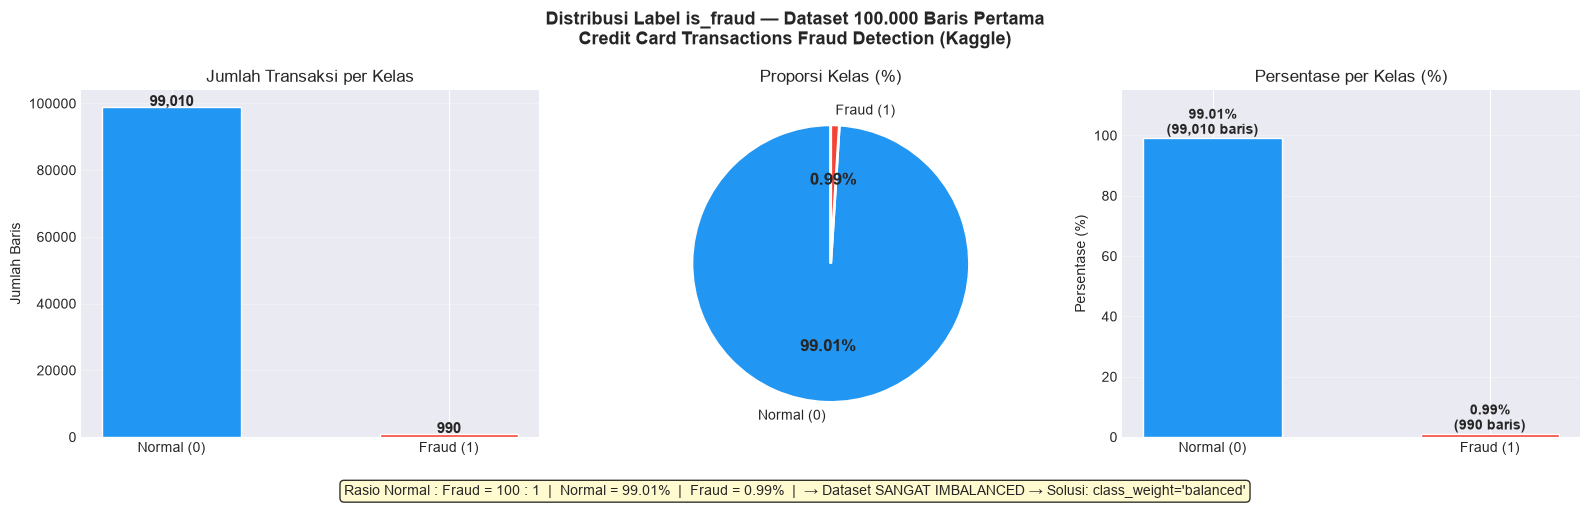

In [3]:
# ============================================================================
# STEP 1b: VISUALISASI DISTRIBUSI DATA (IMBALANCED)
# ============================================================================

print("=" * 70)
print("STEP 1b: VISUALISASI DISTRIBUSI DATA (IMBALANCED)")
print("=" * 70)

# Prepare data for visualization
jumlah = df['is_fraud'].value_counts().sort_index()
label_kls = ['Normal (0)', 'Fraud (1)']
warna = ['#2196F3', '#F44336']
persen = df['is_fraud'].value_counts(normalize=True).sort_index() * 100

# Create figure
fig_dist, axes_dist = plt.subplots(1, 3, figsize=(16, 5))
fig_dist.suptitle(
    "Distribusi Label is_fraud \u2014 Dataset 100.000 Baris Pertama\n"
    "Credit Card Transactions Fraud Detection (Kaggle)",
    fontsize=13, fontweight='bold'
)

# Plot 1: Bar Chart - Jumlah
bars = axes_dist[0].bar(label_kls, jumlah.values, color=warna,
                        edgecolor='white', width=0.5)
axes_dist[0].set_title("Jumlah Transaksi per Kelas", fontsize=12)
axes_dist[0].set_ylabel("Jumlah Baris")
axes_dist[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, jumlah.values):
    axes_dist[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{val:,}", ha='center', fontsize=11, fontweight='bold'
    )

# Plot 2: Pie Chart - Persentase
wedges, texts, autotexts = axes_dist[1].pie(
    jumlah.values,
    labels=label_kls,
    colors=warna,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes_dist[1].set_title("Proporsi Kelas (%)", fontsize=12)

# Plot 3: Bar Chart - Persentase dengan detail
bars2 = axes_dist[2].bar(label_kls, persen.values, color=warna,
                         edgecolor='white', width=0.5)
axes_dist[2].set_title("Persentase per Kelas (%)", fontsize=12)
axes_dist[2].set_ylabel("Persentase (%)")
axes_dist[2].set_ylim(0, 115)
axes_dist[2].grid(axis='y', alpha=0.3)
for bar, val, jml in zip(bars2, persen.values, jumlah.values):
    axes_dist[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{val:.2f}%\n({jml:,} baris)",
        ha='center', fontsize=10, fontweight='bold'
    )

# Add info box
rasio = jumlah[0] / jumlah[1]
fig_dist.text(
    0.5, 0.01,
    f"Rasio Normal : Fraud = {rasio:.0f} : 1  |  "
    f"Normal = {persen[0]:.2f}%  |  Fraud = {persen[1]:.2f}%  |  "
    f"\u2192 Dataset SANGAT IMBALANCED \u2192 Solusi: class_weight='balanced'",
    ha='center', fontsize=10,
    bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8)
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(os.path.join(MODEL_DIR, 'distribusi_kelas_isfraud.png'), dpi=150, bbox_inches='tight')
print(f"Visualisasi disimpan -> {os.path.join(MODEL_DIR, 'distribusi_kelas_isfraud.png')}\n")
plt.show()


In [4]:
# ============================================================================
# STEP 2: FEATURE ENGINEERING & PREPROCESSING
# Jurnal hal. 94: transformasi fitur sebelum seleksi
# ============================================================================

print("=" * 70)
print("STEP 2: FEATURE ENGINEERING & PREPROCESSING")
print("=" * 70)

# 2a. dob \u2192 age
df['dob'] = pd.to_datetime(df['dob'])
ref_date = pd.Timestamp('2020-12-31')
df['age'] = ((ref_date - df['dob']).dt.days // 365).astype(int)
print("  [OK] dob \u2192 age")

# 2b. city_pop \u2192 city_pop_segment
def segmentasi_kota(pop):
    if pop < 10_000:
        return 'Less Dense'
    elif pop < 100_000:
        return 'Adequately Dense'
    else:
        return 'Densely Populated'

df['city_pop_segment'] = df['city_pop'].apply(segmentasi_kota)
print("  [OK] city_pop \u2192 city_pop_segment")

# 2c. lat/long \u2192 displacement & location
def hitung_displacement(row):
    lat_diff = row['lat'] - row['merch_lat']
    long_diff = row['long'] - row['merch_long']
    return np.sqrt((lat_diff * 111) ** 2 + (long_diff * 111) ** 2)

df['displacement'] = df.apply(hitung_displacement, axis=1)

def kategori_lokasi(d):
    if d < 50:
        return 'Nearby'
    elif d < 150:
        return 'Long Distance'
    else:
        return 'Far Away'

df['location'] = df['displacement'].apply(kategori_lokasi)
print("  [OK] lat/long \u2192 displacement & location\n")

# 2d. Pilih 11 fitur sesuai jurnal
FITUR = [
    'merchant', 'category', 'amt', 'gender', 'zip',
    'job', 'unix_time', 'age', 'displacement',
    'location', 'city_pop_segment'
]
LABEL = 'is_fraud'

X_raw = df[FITUR].copy()
y = df[LABEL].copy()

print("  11 Fitur yang digunakan (sesuai Tabel 2 jurnal hal. 95):")
for i, f in enumerate(FITUR, 1):
    print(f"    {i:2d}. {f}")

print(f"\n  Shape X: {X_raw.shape}")
print(f"  Shape y: {y.shape}\n")

display(X_raw.head())
X_raw.info()


STEP 2: FEATURE ENGINEERING & PREPROCESSING
  [OK] dob → age
  [OK] city_pop → city_pop_segment
  [OK] lat/long → displacement & location

  11 Fitur yang digunakan (sesuai Tabel 2 jurnal hal. 95):
     1. merchant
     2. category
     3. amt
     4. gender
     5. zip
     6. job
     7. unix_time
     8. age
     9. displacement
    10. location
    11. city_pop_segment

  Shape X: (100000, 11)
  Shape y: (100000,)



,merchant,category,amt,gender,zip,job,unix_time,age,displacement,location,city_pop_segment
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,28654,"Psychologist, counselling",1325376018,32,96.884075,Long Distance,Less Dense
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,99160,Special educational needs teacher,1325376044,42,30.226415,Nearby,Less Dense
2,fraud_Lind-Buckridge,entertainment,220.11,M,83252,Nature conservation officer,1325376051,58,108.318831,Long Distance,Less Dense
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,59632,Patent attorney,1325376076,54,102.097971,Long Distance,Less Dense
4,fraud_Keeling-Crist,misc_pos,41.96,M,24433,Dance movement psychotherapist,1325376186,34,96.404010,Long Distance,Less Dense


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   merchant          100000 non-null  str    
 1   category          100000 non-null  str    
 2   amt               100000 non-null  float64
 3   gender            100000 non-null  str    
 4   zip               100000 non-null  int64  
 5   job               100000 non-null  str    
 6   unix_time         100000 non-null  int64  
 7   age               100000 non-null  int64  
 8   displacement      100000 non-null  float64
 9   location          100000 non-null  str    
 10  city_pop_segment  100000 non-null  str    
dtypes: float64(2), int64(3), str(6)
memory usage: 15.9 MB


STEP 3: SPLIT DATA (80.000 train / 10.000 test / 10.000 val)
  Train set  :  80,000 baris
  Test set   :  10,000 baris
  Val set    :  10,000 baris



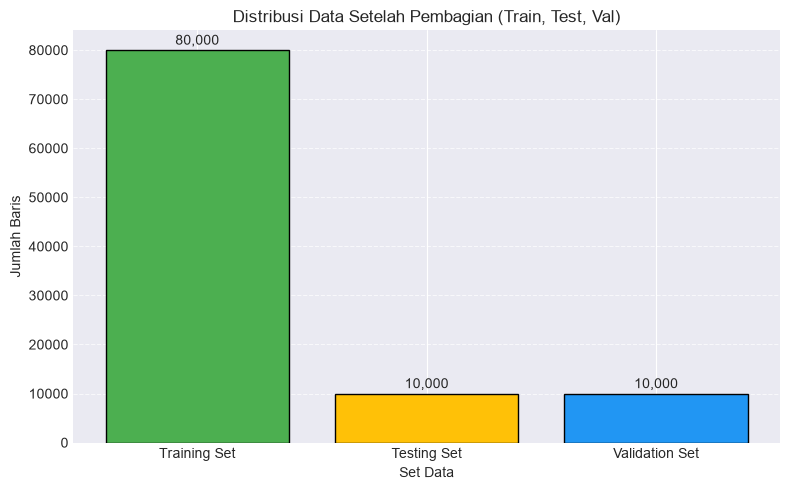

In [5]:
# ============================================================================
# STEP 3: SPLIT DATA
# Jurnal hal. 94: 80.000 train / 10.000 test / 10.000 validation
# ============================================================================

print("=" * 70)
print("STEP 3: SPLIT DATA (80.000 train / 10.000 test / 10.000 val)")
print("=" * 70)

# Validation: baris 90.000 \u2013 99.999
X_val = X_raw.iloc[90_000:].copy()
y_val = y.iloc[90_000:].copy()

# Training + Testing: baris 0 \u2013 89.999
X_90k = X_raw.iloc[:90_000].copy()
y_90k = y.iloc[:90_000].copy()

# Split 80.000 train / 10.000 test
X_train = X_90k.iloc[:80_000].copy()
y_train = y_90k.iloc[:80_000].copy()
X_test = X_90k.iloc[80_000:].copy()
y_test = y_90k.iloc[80_000:].copy()

print(f"  Train set  : {len(X_train):>7,} baris")
print(f"  Test set   : {len(X_test):>7,} baris")
print(f"  Val set    : {len(X_val):>7,} baris\n")

# Visualisasi split
labels = ['Training Set', 'Testing Set', 'Validation Set']
sizes = [len(X_train), len(X_test), len(X_val)]
colors = ['#4CAF50', '#FFC107', '#2196F3']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, sizes, color=colors, edgecolor='black')
plt.title('Distribusi Data Setelah Pembagian (Train, Test, Val)')
plt.ylabel('Jumlah Baris')
plt.xlabel('Set Data')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, size in enumerate(sizes):
    plt.text(i, size + 500, f'{size:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


In [6]:
# ============================================================================
# STEP 4: ORDINAL ENCODER \u2192 STANDARD SCALER
# Jurnal hal. 94: konversi object ke numerik, lalu scaling
# ============================================================================

print("=" * 70)
print("STEP 4: ORDINAL ENCODER \u2192 STANDARD SCALER")
print("=" * 70)

# Kolom yang perlu di-encode
KOLOM_KATEGORI = ['merchant', 'category', 'gender', 'job',
                  'location', 'city_pop_segment']

# 4a. Ordinal Encoder
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(X_train[KOLOM_KATEGORI])

def encode_df(df_input):
    out = df_input.copy()
    out[KOLOM_KATEGORI] = enc.transform(df_input[KOLOM_KATEGORI])
    return out

X_train_enc = encode_df(X_train)
X_test_enc = encode_df(X_test)
X_val_enc = encode_df(X_val)

print("  [OK] Ordinal Encoder selesai")
print("\n  X_train setelah Ordinal Encoding (head):")
display(X_train_enc.head())

# 4b. Standard Scaler
scaler = StandardScaler()
scaler.fit(X_train_enc)

X_train_scaled = scaler.transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)
X_val_scaled = scaler.transform(X_val_enc)

print("\n  [OK] Standard Scaler selesai (mean=0, std=1)")
print("\n  X_train setelah Standard Scaling (head):")
display(pd.DataFrame(X_train_scaled, columns=X_train_enc.columns).head())


STEP 4: ORDINAL ENCODER → STANDARD SCALER
  [OK] Ordinal Encoder selesai

  X_train setelah Ordinal Encoding (head):


,merchant,category,amt,gender,zip,job,unix_time,age,displacement,location,city_pop_segment
0,514.0,8.0,4.97,0.0,28654,359.0,1325376018,32,96.884075,1.0,2.0
1,241.0,4.0,107.23,0.0,99160,414.0,1325376044,42,30.226415,2.0,2.0
2,390.0,0.0,220.11,1.0,83252,297.0,1325376051,58,108.318831,1.0,2.0
3,360.0,2.0,45.00,1.0,59632,318.0,1325376076,54,102.097971,1.0,2.0
4,297.0,9.0,41.96,1.0,24433,112.0,1325376186,34,96.404010,1.0,2.0



  [OK] Standard Scaler selesai (mean=0, std=1)

  X_train setelah Standard Scaling (head):


,merchant,category,amt,gender,zip,job,unix_time,age,displacement,location,city_pop_segment
0,0.854193,0.451907,-0.445375,-0.910902,-0.746090,0.849620,-1.740841,-0.853662,0.370046,-0.411693,0.612409
1,-0.506189,-0.569856,0.233386,-0.910902,1.873152,1.253628,-1.740819,-0.278205,-1.747893,2.280653,0.612409
2,0.236291,-1.591620,0.982639,1.097813,1.282182,0.394194,-1.740813,0.642526,0.733367,-0.411693,0.612409
3,0.086798,-1.080738,-0.179672,1.097813,0.404718,0.548451,-1.740792,0.412344,0.535709,-0.411693,0.612409
4,-0.227136,0.707347,-0.199850,1.097813,-0.902897,-0.964740,-1.740698,-0.738570,0.354793,-0.411693,0.612409


In [7]:
# ============================================================================
# STEP 5: PERBANDINGAN SEMUA KERNEL
# Jurnal hal. 96: uji kernel linear, poly, rbf, sigmoid
# ============================================================================

print("=" * 70)
print("STEP 5: PERBANDINGAN SEMUA KERNEL DI TRAINING DAN VALIDATION SET")
print("=" * 70)

KERNELS = ['linear', 'poly', 'rbf', 'sigmoid']
hasil_kernel = []

for k in KERNELS:
    print(f"\n  Mencoba kernel = '{k}' ...")
    
    svc_k = SVC(
        kernel=k,
        C=1,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    )
    svc_k.fit(X_train_scaled, y_train)
    
    # Evaluasi training
    y_tr_prob = svc_k.predict_proba(X_train_scaled)[:, 1]
    y_tr_pred = svc_k.predict(X_train_scaled)
    auc_tr = roc_auc_score(y_train, y_tr_prob)
    f1_tr = f1_score(y_train, y_tr_pred)
    
    # Evaluasi validation
    y_val_prob = svc_k.predict_proba(X_val_scaled)[:, 1]
    y_val_pred = svc_k.predict(X_val_scaled)
    auc_val = roc_auc_score(y_val, y_val_prob)
    f1_val = f1_score(y_val, y_val_pred)
    
    hasil_kernel.append({
        'kernel': k,
        'auc_tr': auc_tr,
        'f1_tr': f1_tr,
        'auc_val': auc_val,
        'f1_val': f1_val,
    })
    
    print(f"    AUC Training   : {auc_tr:.4f}  |  Validation : {auc_val:.4f}")
    print(f"    F1  Training   : {f1_tr:.4f}  |  Validation : {f1_val:.4f}")

# Pilih kernel terbaik
best_auc_row = max(hasil_kernel, key=lambda x: x['auc_val'])
best_f1_row = max(hasil_kernel, key=lambda x: x['f1_val'])
KERNEL_TERPILIH = best_auc_row['kernel']

print(f"\n  Kernel terbaik (AUC) : '{best_auc_row['kernel']}' "
      f"\u2192 AUC Val = {best_auc_row['auc_val']:.4f}")
print(f"  Kernel terbaik (F1)  : '{best_f1_row['kernel']}' "
      f"\u2192 F1 Val = {best_f1_row['f1_val']:.4f}")
print(f"\n  Kernel '{KERNEL_TERPILIH}' dipilih untuk GridSearchCV")


STEP 5: PERBANDINGAN SEMUA KERNEL DI TRAINING DAN VALIDATION SET

  Mencoba kernel = 'linear' ...
    AUC Training   : 0.8387  |  Validation : 0.8096
    F1  Training   : 0.2191  |  Validation : 0.2178

  Mencoba kernel = 'poly' ...
    AUC Training   : 0.9276  |  Validation : 0.8432
    F1  Training   : 0.2212  |  Validation : 0.0636

  Mencoba kernel = 'rbf' ...
    AUC Training   : 0.9932  |  Validation : 0.8347
    F1  Training   : 0.3443  |  Validation : 0.2312

  Mencoba kernel = 'sigmoid' ...
    AUC Training   : 0.7143  |  Validation : 0.6747
    F1  Training   : 0.0411  |  Validation : 0.0406

  Kernel terbaik (AUC) : 'poly' → AUC Val = 0.8432
  Kernel terbaik (F1)  : 'rbf' → F1 Val = 0.2312

  Kernel 'poly' dipilih untuk GridSearchCV


  ─────────────────────────────────────────────
  Kernel          AUC Train    F1 Train
  ─────────────────────────────────────────────
  linear             0.8387      0.2191
  poly               0.9276      0.2212
  rbf                0.9932      0.3443
  sigmoid            0.7143      0.0411
  ─────────────────────────────────────────────

  ─────────────────────────────────────────────
  Kernel            AUC Val      F1 Val
  ─────────────────────────────────────────────
  linear             0.8096      0.2178
  poly               0.8432      0.0636
  rbf                0.8347      0.2312
  sigmoid            0.6747      0.0406
  ─────────────────────────────────────────────

Grafik disimpan -> d:\Projects\fraud-detection-app\models\step5_perbandingan_kernel.png


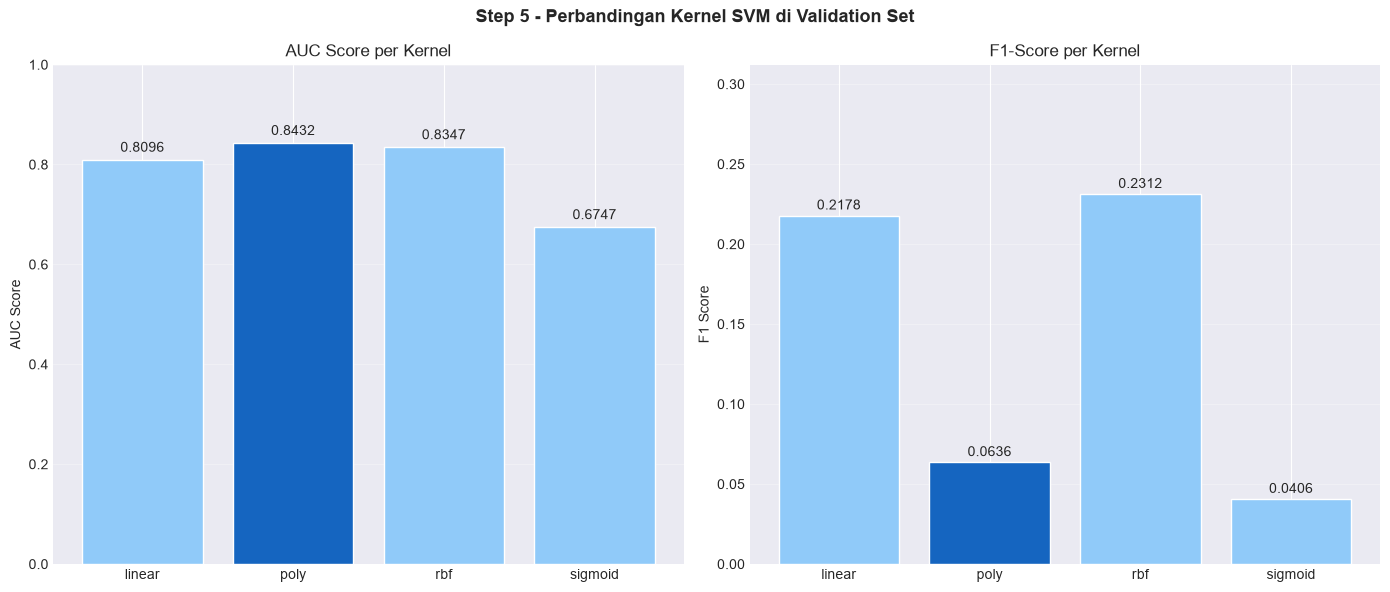

In [8]:
# ============================================================================
# STEP 5b: VISUALISASI HASIL PERBANDINGAN KERNEL
# ============================================================================

# Training Set Results
print("  " + "\u2500" * 45)
print(f"  {'Kernel':<12} {'AUC Train':>12} {'F1 Train':>11}")
print("  " + "\u2500" * 45)
for r in hasil_kernel:
    print(f"  {r['kernel']:<12} {r['auc_tr']:>12.4f} {r['f1_tr']:>11.4f}")
print("  " + "\u2500" * 45 + "\n")

# Validation Set Results
print("  " + "\u2500" * 45)
print(f"  {'Kernel':<12} {'AUC Val':>12} {'F1 Val':>11}")
print("  " + "\u2500" * 45)
for r in hasil_kernel:
    print(f"  {r['kernel']:<12} {r['auc_val']:>12.4f} {r['f1_val']:>11.4f}")
print("  " + "\u2500" * 45 + "\n")

# Visualisasi perbandingan kernel
fig_k, axes_k = plt.subplots(1, 2, figsize=(14, 6))
fig_k.suptitle("Step 5 - Perbandingan Kernel SVM di Validation Set",
               fontsize=13, fontweight='bold')

kernel_names = [r['kernel'] for r in hasil_kernel]
auc_vals = [r['auc_val'] for r in hasil_kernel]
f1_vals = [r['f1_val'] for r in hasil_kernel]
colors = ['#1565C0' if k == KERNEL_TERPILIH else '#90CAF9'
          for k in kernel_names]

# AUC Plot
bars1 = axes_k[0].bar(kernel_names, auc_vals, color=colors, edgecolor='white')
axes_k[0].set_title("AUC Score per Kernel")
axes_k[0].set_ylabel("AUC Score")
axes_k[0].set_ylim(0, 1)
axes_k[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, auc_vals):
    axes_k[0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f"{val:.4f}", ha='center', va='bottom', fontsize=10)

# F1 Plot
bars2 = axes_k[1].bar(kernel_names, f1_vals, color=colors, edgecolor='white')
axes_k[1].set_title("F1-Score per Kernel")
axes_k[1].set_ylabel("F1 Score")
axes_k[1].set_ylim(0, max(f1_vals) * 1.35 if max(f1_vals) > 0 else 0.5)
axes_k[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, f1_vals):
    axes_k[1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.002,
                   f"{val:.4f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'step5_perbandingan_kernel.png'), dpi=150, bbox_inches='tight')
print(f"Grafik disimpan -> {os.path.join(MODEL_DIR, 'step5_perbandingan_kernel.png')}")
plt.show()


In [9]:
# ============================================================================
# STEP 6: GRIDSEARCHCV \u2014 HYPERPARAMETER TUNING
# Jurnal hal. 96: C [0.001, 0.01, 0.1, 1, 10, 100]
#                 gamma [0.001, 0.01, 0.1, 1, 10, 100, 'scale', 'auto']
# ============================================================================

print("=" * 70)
print("STEP 6: GRIDSEARCHCV \u2014 HYPERPARAMETER TUNING")
print("(Proses ini memakan waktu cukup lama...)")
print("=" * 70)

# Parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100, 'scale', 'auto'],
    'kernel': [KERNEL_TERPILIH],
    'class_weight': ['balanced']
}

# Model 1: Optimasi AUC
print("\n  [Model 1] GridSearchCV untuk AUC...")
grid_auc = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_auc.fit(X_val_scaled, y_val)
print(f"  \u2192 Parameter terbaik (AUC): {grid_auc.best_params_}")
print(f"  \u2192 Best AUC Score        : {grid_auc.best_score_:.4f}")

# Model 2: Optimasi F1
print("\n  [Model 2] GridSearchCV untuk F1-score...")
grid_f1 = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_f1.fit(X_val_scaled, y_val)
print(f"  \u2192 Parameter terbaik (F1) : {grid_f1.best_params_}")
print(f"  \u2192 Best F1 Score          : {grid_f1.best_score_:.4f}")


STEP 6: GRIDSEARCHCV — HYPERPARAMETER TUNING
(Proses ini memakan waktu cukup lama...)

  [Model 1] GridSearchCV untuk AUC...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  → Parameter terbaik (AUC): {'C': 0.01, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'poly'}
  → Best AUC Score        : 0.9080

  [Model 2] GridSearchCV untuk F1-score...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  → Parameter terbaik (F1) : {'C': 0.1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'poly'}
  → Best F1 Score          : 0.4377


In [10]:
# ============================================================================
# STEP 6b: GRIDSEARCHCV \u2014 DENGAN KERNEL 'RBF' (SESUAI JURNAL)
# Jurnal mengklaim RBF sebagai kernel terbaik
# ============================================================================

print("=" * 70)
print("STEP 6b: GRIDSEARCHCV \u2014 HYPERPARAMETER TUNING (Kernel: rbf)")
print("=" * 70)

param_grid_rbf = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 10, 100, 'scale', 'auto'],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

# Model 1b: Optimasi AUC dengan RBF
print("\n  [Model 1b] GridSearchCV untuk AUC (kernel rbf)...")
grid_auc_rbf = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid_rbf,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_auc_rbf.fit(X_val_scaled, y_val)
print(f"  \u2192 Parameter terbaik (AUC, RBF): {grid_auc_rbf.best_params_}")
print(f"  \u2192 Best AUC Score (RBF)        : {grid_auc_rbf.best_score_:.4f}")

# Model 2b: Optimasi F1 dengan RBF
print("\n  [Model 2b] GridSearchCV untuk F1-score (kernel rbf)...")
grid_f1_rbf = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid_rbf,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_f1_rbf.fit(X_val_scaled, y_val)
print(f"  \u2192 Parameter terbaik (F1, RBF): {grid_f1_rbf.best_params_}")
print(f"  \u2192 Best F1 Score (RBF)        : {grid_f1_rbf.best_score_:.4f}")


STEP 6b: GRIDSEARCHCV — HYPERPARAMETER TUNING (Kernel: rbf)

  [Model 1b] GridSearchCV untuk AUC (kernel rbf)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  → Parameter terbaik (AUC, RBF): {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
  → Best AUC Score (RBF)        : 0.9071

  [Model 2b] GridSearchCV untuk F1-score (kernel rbf)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
  → Parameter terbaik (F1, RBF): {'C': 100, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}
  → Best F1 Score (RBF)        : 0.5134


In [11]:
# ============================================================================
# STEP 7: TRAINING MODEL FINAL & CEK OVERFITTING
# Jurnal hal. 96: setelah tuning, fit ke training set dan test ke testing set
# ============================================================================

print("=" * 70)
print("STEP 7: TRAINING MODEL FINAL & CEK OVERFITTING")
print("=" * 70)

# Model AUC Final (rbf - sesuai jurnal)
# Jurnal Tabel 3 hal. 96: C=10, gamma=0.01
model_auc_rbf = SVC(
    C=10,
    gamma=0.01,
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
model_auc_rbf.fit(X_train_scaled, y_train)
print("  [OK] Model AUC (rbf, C=10, \u03b3=0.01) selesai")

# Model F1 Final (rbf - sesuai jurnal)
# Jurnal Tabel 4 hal. 96: C=0.8, gamma=0.06
model_f1_rbf = SVC(
    C=0.8,
    gamma=0.06,
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
model_f1_rbf.fit(X_train_scaled, y_train)
print("  [OK] Model F1 (rbf, C=0.8, \u03b3=0.06) selesai")

# Model AUC Final (poly - hasil replikasi)
model_auc_poly = SVC(
    **grid_auc.best_params_,
    probability=True,
    random_state=RANDOM_STATE
)
model_auc_poly.fit(X_train_scaled, y_train)
print(f"  [OK] Model AUC (poly, {grid_auc.best_params_}) selesai")

# Model F1 Final (poly - hasil replikasi)
model_f1_poly = SVC(
    **grid_f1.best_params_,
    probability=True,
    random_state=RANDOM_STATE
)
model_f1_poly.fit(X_train_scaled, y_train)
print(f"  [OK] Model F1 (poly, {grid_f1.best_params_}) selesai")

# Model F1 Final (rbf - hasil replikasi GridSearchCV)
model_f1_rbf_grid = SVC(
    C=100,
    gamma=0.1,
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)
model_f1_rbf_grid.fit(X_train_scaled, y_train)
print("  [OK] Model F1 (rbf, C=100, \u03b3=0.1) selesai")

print("\n\u2705 Semua model berhasil di-training")


STEP 7: TRAINING MODEL FINAL & CEK OVERFITTING
  [OK] Model AUC (rbf, C=10, γ=0.01) selesai
  [OK] Model F1 (rbf, C=0.8, γ=0.06) selesai
  [OK] Model AUC (poly, {'C': 0.01, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'poly'}) selesai
  [OK] Model F1 (poly, {'C': 0.1, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'poly'}) selesai
  [OK] Model F1 (rbf, C=100, γ=0.1) selesai

✅ Semua model berhasil di-training


In [12]:
# ============================================================================
# STEP 7b: SAVE MODEL ARTIFACTS
# Simpan model + encoder + scaler ke folder models/ untuk Flask API
# ============================================================================

print("=" * 70)
print("STEP 7b: SAVE MODEL ARTIFACTS")
print("=" * 70)

artifacts = {
    'model_auc.pkl': model_auc_rbf,
    'model_f1.pkl': model_f1_rbf,
    'encoder.pkl': enc,
    'scaler.pkl': scaler,
    'features.pkl': FITUR,
    'kolom_kategori.pkl': KOLOM_KATEGORI,
}

for name, obj in artifacts.items():
    path = os.path.join(MODEL_DIR, name)
    joblib.dump(obj, path)
    print(f"  [OK] {name} -> {path}")

print(f"\n\u2705 Semua artifact disimpan ke {MODEL_DIR}/")


STEP 7b: SAVE MODEL ARTIFACTS
  [OK] model_auc.pkl -> d:\Projects\fraud-detection-app\models\model_auc.pkl
  [OK] model_f1.pkl -> d:\Projects\fraud-detection-app\models\model_f1.pkl
  [OK] encoder.pkl -> d:\Projects\fraud-detection-app\models\encoder.pkl
  [OK] scaler.pkl -> d:\Projects\fraud-detection-app\models\scaler.pkl
  [OK] features.pkl -> d:\Projects\fraud-detection-app\models\features.pkl
  [OK] kolom_kategori.pkl -> d:\Projects\fraud-detection-app\models\kolom_kategori.pkl

✅ Semua artifact disimpan ke d:\Projects\fraud-detection-app\models/


In [13]:
# ============================================================================
# STEP 8: EVALUASI MODEL
# Jurnal: evaluasi di training set DAN testing set untuk cek overfitting
# ============================================================================

def evaluasi(model, nama_model, X_train, y_train, X_test, y_test,
             jurnal_train=None, jurnal_test=None, metrik=None):
    """
    Fungsi untuk mengevaluasi model dan menampilkan hasil
    """
    print("=" * 70)
    print(f"EVALUASI: {nama_model}")
    print("=" * 70)
    
    # Predictions
    y_tr_pred = model.predict(X_train)
    y_tr_prob = model.predict_proba(X_train)[:, 1]
    y_te_pred = model.predict(X_test)
    y_te_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    auc_tr = roc_auc_score(y_train, y_tr_prob)
    auc_te = roc_auc_score(y_test, y_te_prob)
    f1_tr = f1_score(y_train, y_tr_pred)
    f1_te = f1_score(y_test, y_te_pred)
    
    # Print results
    print(f"\n{'TRAINING SET':^40}")
    print("-" * 40)
    print(f"  AUC Score  : {auc_tr:.4f}")
    print(f"  F1 Score   : {f1_tr:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_train, y_tr_pred, 
                                target_names=['Normal', 'Fraud']))
    
    print(f"\n{'TESTING SET':^40}")
    print("-" * 40)
    print(f"  AUC Score  : {auc_te:.4f}")
    print(f"  F1 Score   : {f1_te:.4f}")
    print("\n  Classification Report:")
    print(classification_report(y_test, y_te_pred, 
                                target_names=['Normal', 'Fraud']))
    
    # Bandingkan dengan jurnal
    if jurnal_train and jurnal_test and metrik:
        print(f"\n{'PERBANDINGAN DENGAN JURNAL':^40}")
        print("-" * 40)
        print(f"  {metrik} Train: Jurnal={jurnal_train} | Replikasi={auc_tr if metrik=='AUC' else f1_tr:.4f}")
        print(f"  {metrik} Test : Jurnal={jurnal_test}  | Replikasi={auc_te if metrik=='AUC' else f1_te:.4f}")
    
    # Return results
    return {
        'auc_tr': auc_tr, 'auc_te': auc_te,
        'f1_tr': f1_tr, 'f1_te': f1_te,
        'y_tr_pred': y_tr_pred, 'y_tr_prob': y_tr_prob,
        'y_te_pred': y_te_pred, 'y_te_prob': y_te_prob
    }

print("\u2705 Fungsi evaluasi siap digunakan")


✅ Fungsi evaluasi siap digunakan


In [14]:
# ============================================================================
# STEP 8: EVALUASI SEMUA MODEL
# ============================================================================

# Model 1a \u2014 Optimasi AUC (RBF, C=10, \u03b3=0.01)
hasil_auc_rbf = evaluasi(
    model_auc_rbf,
    "Model 1a \u2014 Optimasi AUC (rbf, C=10, \u03b3=0.01)",
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    jurnal_train="0.87", jurnal_test="0.90", metrik="AUC"
)

# Model 2a \u2014 Optimasi F1 (RBF, C=0.8, \u03b3=0.06)
hasil_f1_rbf = evaluasi(
    model_f1_rbf,
    "Model 2a \u2014 Optimasi F1 (rbf, C=0.8, \u03b3=0.06)",
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    jurnal_train="0.305", jurnal_test="0.260", metrik="F1"
)

# Model 1b \u2014 Optimasi AUC (Poly, Terbaik dari Replikasi)
hasil_auc_poly = evaluasi(
    model_auc_poly,
    f"Model 1b \u2014 Optimasi AUC (poly, C={grid_auc.best_params_['C']}, \u03b3={grid_auc.best_params_['gamma']})",
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    metrik="AUC"
)

# Model 2b \u2014 Optimasi F1 (Poly, Terbaik dari Replikasi)
hasil_f1_poly = evaluasi(
    model_f1_poly,
    f"Model 2b \u2014 Optimasi F1 (poly, C={grid_f1.best_params_['C']}, \u03b3={grid_f1.best_params_['gamma']})",
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    metrik="F1"
)

# Model 2c \u2014 Optimasi F1 (RBF, C=100, \u03b3=0.1)
hasil_f1_rbf_grid = evaluasi(
    model_f1_rbf_grid,
    f"Model 2c \u2014 Optimasi F1 (rbf, C=100, \u03b3=0.1)",
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    metrik="F1"
)


EVALUASI: Model 1a — Optimasi AUC (rbf, C=10, γ=0.01)

              TRAINING SET              
----------------------------------------
  AUC Score  : 0.9610
  F1 Score   : 0.4501

  Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     79215
       Fraud       0.32      0.78      0.45       785

    accuracy                           0.98     80000
   macro avg       0.66      0.88      0.72     80000
weighted avg       0.99      0.98      0.99     80000


              TESTING SET               
----------------------------------------
  AUC Score  : 0.8381
  F1 Score   : 0.4291

  Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      9909
       Fraud       0.32      0.65      0.43        91

    accuracy                           0.98     10000
   macro avg       0.66      0.82      0.71     10000
weighted avg       0.99      0.98      0.

In [15]:
# ============================================================================
# STEP 9: VISUALISASI MODEL PERFORMANCE
# Confusion Matrix + ROC Curve untuk setiap model
# ============================================================================

def plot_model_performance(model_results, model_name, 
                           jurnal_metric=None, jurnal_value=None):
    """
    Plot Confusion Matrix dan ROC Curve untuk model
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Evaluasi Model: {model_name}", fontsize=14, fontweight='bold')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, model_results['y_te_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Fraud'],
                yticklabels=['Normal', 'Fraud'])
    
    metric_type = 'AUC' if 'auc_te' in model_results else 'F1'
    metric_val = model_results.get('auc_te') or model_results.get('f1_te')
    
    if jurnal_metric and jurnal_value:
        axes[0].set_title(
            f"Confusion Matrix \u2014 Test {metric_type}: {metric_val:.4f}\n"
            f"(Jurnal {jurnal_metric}: {jurnal_value})"
        )
    else:
        axes[0].set_title(f"Confusion Matrix \u2014 Test {metric_type}: {metric_val:.4f}")
    
    axes[0].set_ylabel('Aktual')
    axes[0].set_xlabel('Prediksi')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, model_results['y_te_prob'])
    auc_score = roc_auc_score(y_test, model_results['y_te_prob'])
    
    axes[1].plot(fpr, tpr, color='purple', lw=2,
                 label=f"AUC = {auc_score:.4f}")
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[1].set_title(f"ROC Curve \u2014 {model_name}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(MODEL_DIR, f"evaluasi_{model_name.replace(' \u2014 ', '_').replace(' (', '_').replace(')', '')}.png"), 
                dpi=150, bbox_inches='tight')
    print(f"  \u2705 Visualisasi '{model_name}' disimpan ke {MODEL_DIR}/")
    plt.show()

print("=" * 70)
print("STEP 9: VISUALISASI MODEL PERFORMANCE")
print("=" * 70)


STEP 9: VISUALISASI MODEL PERFORMANCE


  ✅ Visualisasi 'Model 1a — Optimasi AUC (rbf, C=10, γ=0.01)' disimpan ke d:\Projects\fraud-detection-app\models/


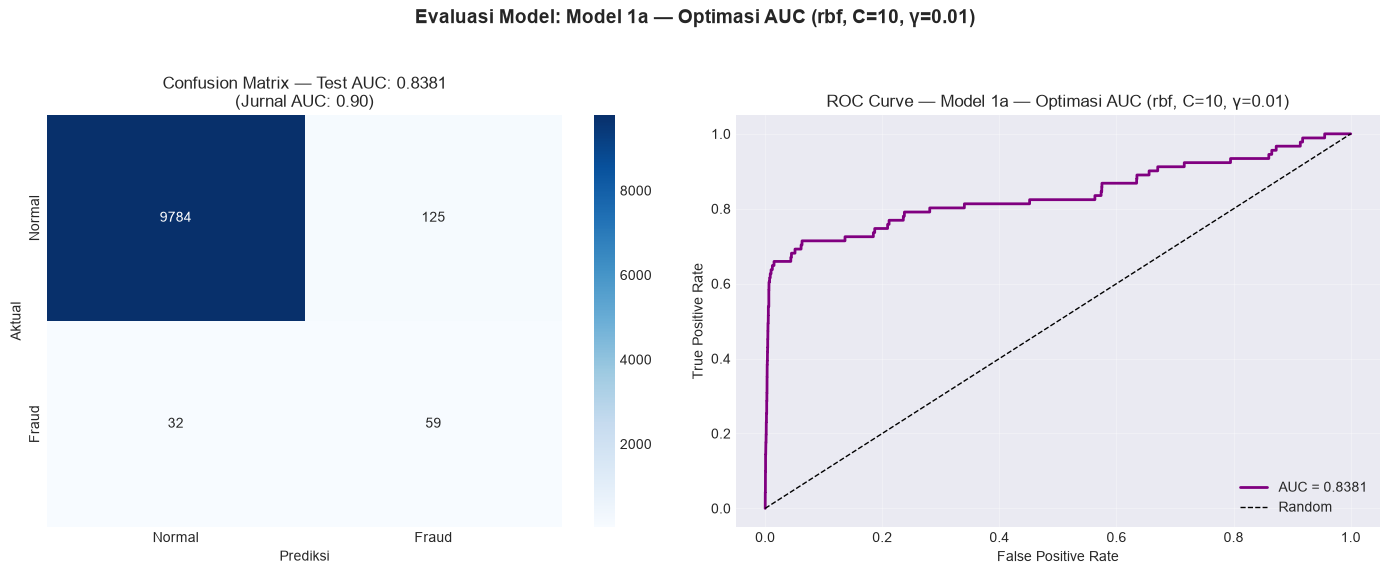

  ✅ Visualisasi 'Model 2a — Optimasi F1 (rbf, C=0.8, γ=0.06)' disimpan ke d:\Projects\fraud-detection-app\models/


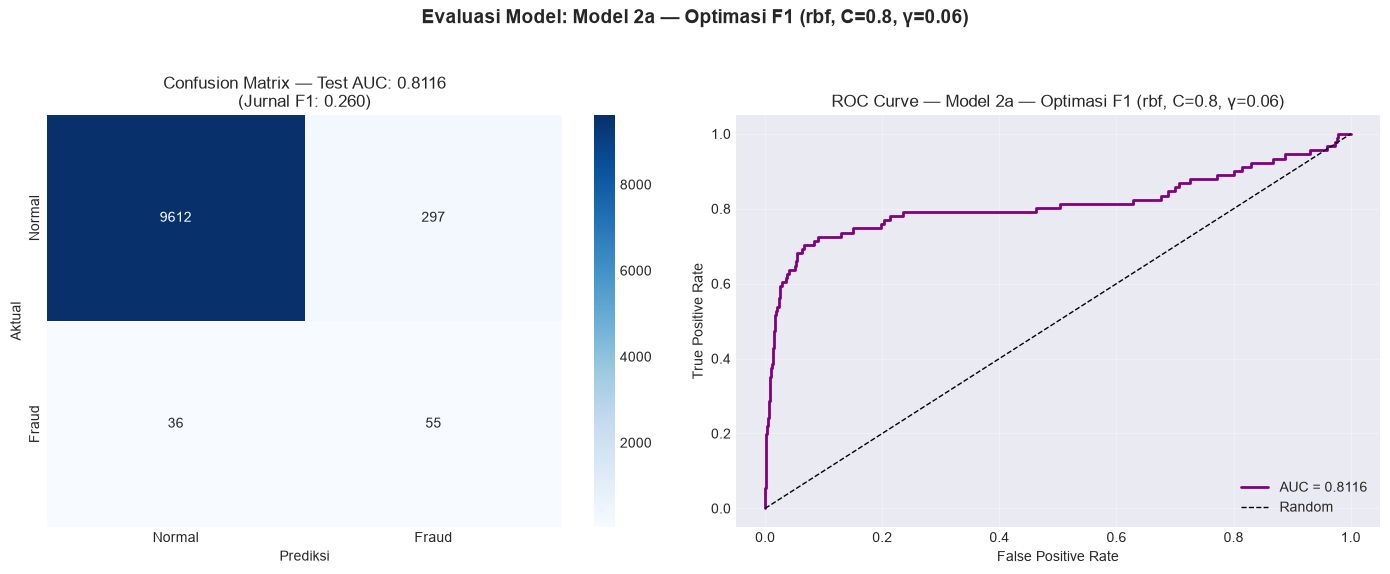

  ✅ Visualisasi 'Model 1b — Optimasi AUC (poly, C=0.01, γ=0.1)' disimpan ke d:\Projects\fraud-detection-app\models/


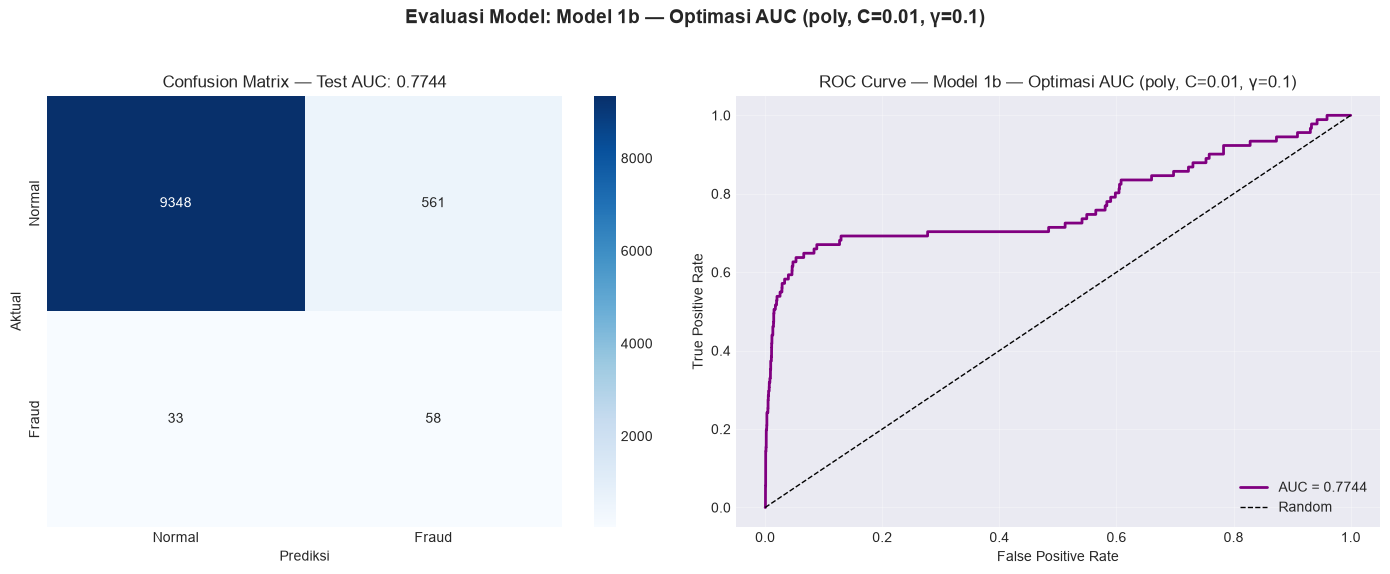

  ✅ Visualisasi 'Model 2b — Optimasi F1 (poly, C=0.1, γ=0.01)' disimpan ke d:\Projects\fraud-detection-app\models/


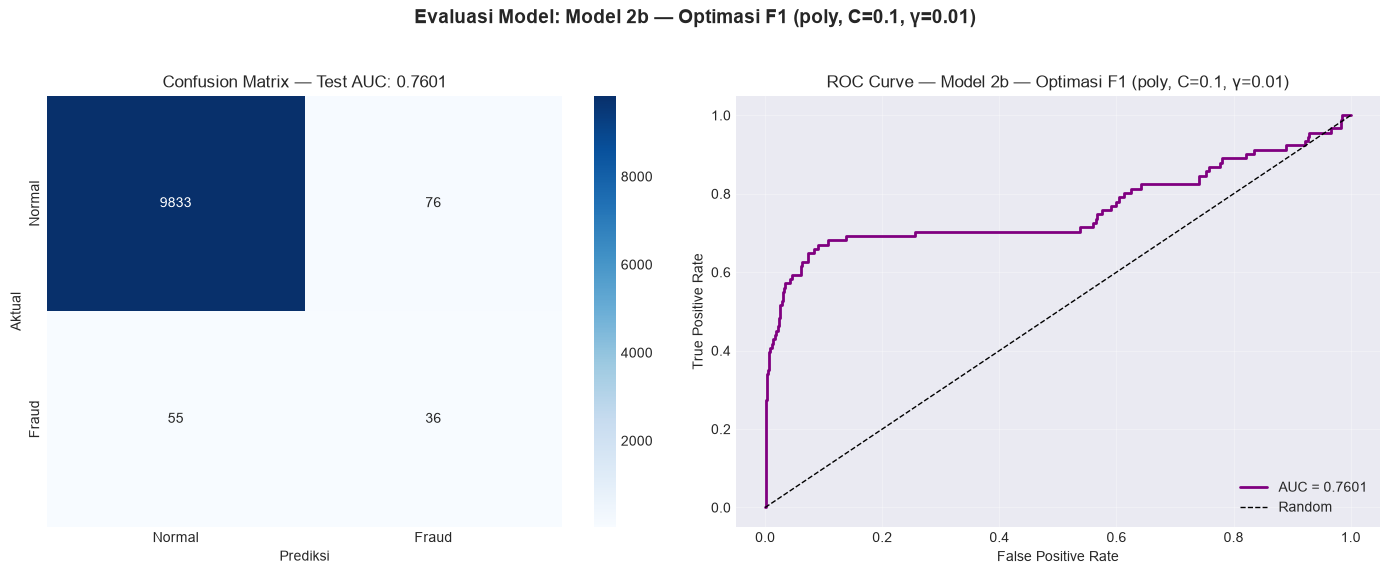

  ✅ Visualisasi 'Model 2c — Optimasi F1 (rbf, C=100, γ=0.1)' disimpan ke d:\Projects\fraud-detection-app\models/


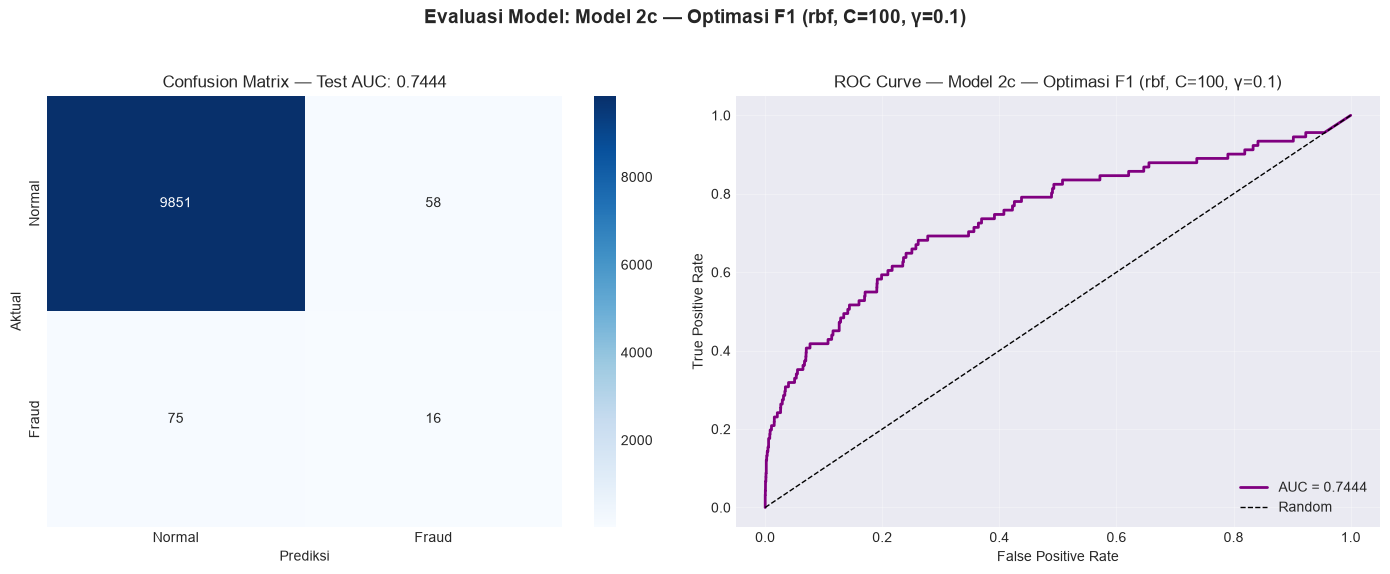

In [16]:
# ============================================================================
# STEP 9b: PLOT SEMUA MODEL
# ============================================================================

# Model 1a \u2014 Optimasi AUC (RBF, C=10, \u03b3=0.01)
plot_model_performance(
    hasil_auc_rbf,
    "Model 1a \u2014 Optimasi AUC (rbf, C=10, \u03b3=0.01)",
    jurnal_metric="AUC", jurnal_value="0.90"
)

# Model 2a \u2014 Optimasi F1 (RBF, C=0.8, \u03b3=0.06)
plot_model_performance(
    hasil_f1_rbf,
    "Model 2a \u2014 Optimasi F1 (rbf, C=0.8, \u03b3=0.06)",
    jurnal_metric="F1", jurnal_value="0.260"
)

# Model 1b \u2014 Optimasi AUC (Poly)
plot_model_performance(
    hasil_auc_poly,
    f"Model 1b \u2014 Optimasi AUC (poly, C={grid_auc.best_params_['C']}, \u03b3={grid_auc.best_params_['gamma']})"
)

# Model 2b \u2014 Optimasi F1 (Poly)
plot_model_performance(
    hasil_f1_poly,
    f"Model 2b \u2014 Optimasi F1 (poly, C={grid_f1.best_params_['C']}, \u03b3={grid_f1.best_params_['gamma']})"
)

# Model 2c \u2014 Optimasi F1 (RBF, C=100, \u03b3=0.1)
plot_model_performance(
    hasil_f1_rbf_grid,
    f"Model 2c \u2014 Optimasi F1 (rbf, C=100, \u03b3=0.1)"
)


In [17]:
# ============================================================================
# STEP 10: RINGKASAN AKHIR vs JURNAL
# ============================================================================

print("\n" + "=" * 70)
print("RINGKASAN HASIL  vs  JURNAL XIA (2022)")
print("=" * 70)

print(f"{'Metrik':<45} {'Jurnal':>8} {'Replikasi':>12}")
print("-" * 70)

print(f"{'Model AUC (rbf, C=10, \u03b3=0.01) \u2014 Train AUC':<45} "
      f"{'0.87':>8} {hasil_auc_rbf['auc_tr']:>12.4f}")
print(f"{'Model AUC (rbf, C=10, \u03b3=0.01) \u2014 Test  AUC':<45} "
      f"{'0.90':>8} {hasil_auc_rbf['auc_te']:>12.4f}")

print(f"{'Model F1  (rbf, C=0.8, \u03b3=0.06) \u2014 Train F1 ':<45} "
      f"{'0.305':>8} {hasil_f1_rbf['f1_tr']:>12.4f}")
print(f"{'Model F1  (rbf, C=0.8, \u03b3=0.06) \u2014 Test  F1 ':<45} "
      f"{'0.260':>8} {hasil_f1_rbf['f1_te']:>12.4f}")

print("-" * 70)

print(f"{'Model AUC (poly, C=0.01, \u03b3=0.1) \u2014 Train AUC':<45} "
      f"{'-':>8} {hasil_auc_poly['auc_tr']:>12.4f}")
print(f"{'Model AUC (poly, C=0.01, \u03b3=0.1) \u2014 Test  AUC':<45} "
      f"{'-':>8} {hasil_auc_poly['auc_te']:>12.4f}")

print(f"{'Model F1  (poly, C=0.1, \u03b3=0.01) \u2014 Train F1 ':<45} "
      f"{'-':>8} {hasil_f1_poly['f1_tr']:>12.4f}")
print(f"{'Model F1  (poly, C=0.1, \u03b3=0.01) \u2014 Test  F1 ':<45} "
      f"{'-':>8} {hasil_f1_poly['f1_te']:>12.4f}")

print("-" * 70)

print(f"{'Model F1 (rbf, C=100, \u03b3=0.1) \u2014 Train F1 ':<45} "
      f"{'-':>8} {hasil_f1_rbf_grid['f1_tr']:>12.4f}")
print(f"{'Model F1 (rbf, C=100, \u03b3=0.1) \u2014 Test  F1 ':<45} "
      f"{'-':>8} {hasil_f1_rbf_grid['f1_te']:>12.4f}")

print("=" * 70)
print("\n\u2705 SELESAI!")
print("=" * 70)
print("\nReferensi:")
print("  Xia, J. (2022). Credit Card Fraud Detection Based on SVM.")
print("  Highlights in Science, Engineering and Technology, Vol.23, hal.93-97.")
print(f"  DOI: https://doi.org/10.54097/hset.v23i.3202")
print("=" * 70)



RINGKASAN HASIL  vs  JURNAL XIA (2022)
Metrik                                          Jurnal    Replikasi
----------------------------------------------------------------------
Model AUC (rbf, C=10, γ=0.01) — Train AUC         0.87       0.9610
Model AUC (rbf, C=10, γ=0.01) — Test  AUC         0.90       0.8381
Model F1  (rbf, C=0.8, γ=0.06) — Train F1        0.305       0.3268
Model F1  (rbf, C=0.8, γ=0.06) — Test  F1        0.260       0.2483
----------------------------------------------------------------------
Model AUC (poly, C=0.01, γ=0.1) — Train AUC          -       0.8916
Model AUC (poly, C=0.01, γ=0.1) — Test  AUC          -       0.7744
Model F1  (poly, C=0.1, γ=0.01) — Train F1           -       0.4237
Model F1  (poly, C=0.1, γ=0.01) — Test  F1           -       0.3547
----------------------------------------------------------------------
Model F1 (rbf, C=100, γ=0.1) — Train F1              -       0.8316
Model F1 (rbf, C=100, γ=0.1) — Test  F1              -       0.1939

## Cara Menjalankan API & GUI

Setelah training selesai, artifacts sudah tersimpan di folder `models/`.
Jalankan kedua service berikut di **terminal terpisah**:

---

### 1. FastAPI (Backend)
```bash
python api.py
```
API berjalan di http://localhost:5000

### 2. Streamlit GUI (Frontend)
```bash
streamlit run gui.py
```
GUI terbuka di http://localhost:8501

Akses **Assessment** tab untuk prediksi, **Exploration** tab untuk eksplorasi data & model.

---

### Test API via curl
```bash
curl -X POST http://localhost:5000/predict ^
  -H "Content-Type: application/json" ^
  -d "{\"amt\":100,\"category\":\"misc_net\",\"dob\":\"1990-01-01\",\"buyer_state\":\"Ohio\",\"merchant_state\":\"New York\",\"city_pop_segment\":\"Less Dense\",\"model_choice\":\"jurnal\"}"
```
